# Tuned Training Results Analysis

This notebook compares the first full CAFA5 graph training run against the tuned training run. It reads saved Savio artifacts only.

The comparison focuses on:
- Final validation and test metrics for BPO, CCO, and MFO
- Tuned changes: weighted BCE, larger hidden dimension, stronger dropout, lower learning rate, weight decay, Fmax checkpointing, early stopping, and plateau LR scheduling


## 1. Setup and Run Discovery

This cell finds the repository, discovers the newest baseline and tuned run directories, and prepares an output directory for comparison tables and figures.


In [1]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 160})


def find_repo_root(start: Path) -> tuple[Path, str]:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate, 'cwd_search'
    fallback = Path('/global/home/users/bensonli/c242_cafa5')
    if fallback.exists():
        return fallback, 'known_path'
    return start, 'cwd_fallback'


def resolve_repo_root() -> tuple[Path, str]:
    configured = os.environ.get('CAFA5_REPO_ROOT') or os.environ.get('REPO_ROOT')
    if configured:
        return Path(configured).expanduser().resolve(), 'env'
    return find_repo_root(Path.cwd().resolve())


def newest_run_dir(training_runs_dir: Path, pattern: str) -> Path:
    candidates = [path for path in training_runs_dir.glob(pattern) if path.is_dir()]
    if not candidates:
        raise FileNotFoundError(f'No run directories matched {training_runs_dir / pattern}')
    return max(candidates, key=lambda path: path.stat().st_mtime)


def resolve_run_dir(env_key: str, training_runs_dir: Path, pattern: str) -> Path:
    configured = os.environ.get(env_key)
    if configured:
        return Path(configured).expanduser().resolve()
    return newest_run_dir(training_runs_dir, pattern).resolve()


REPO_ROOT, REPO_ROOT_SOURCE = resolve_repo_root()
SERVER_USER = os.environ.get('USER', 'bensonli')
RUN_ROOT = Path(os.environ.get('CAFA5_RUN_ROOT', f'/global/scratch/users/{SERVER_USER}/cafa5_outputs')).expanduser().resolve()
GRAPH_CACHE_DIR = RUN_ROOT / 'graph_cache'
TRAINING_RUNS_DIR = GRAPH_CACHE_DIR / 'training_runs'

BASELINE_RUN_GLOB = os.environ.get('CAFA5_BASELINE_ANALYSIS_RUN_GLOB', 'full_graph_pyg_mtf20_*')
TUNED_RUN_GLOB = os.environ.get('CAFA5_TUNED_ANALYSIS_RUN_GLOB', 'full_graph_tuned_*')
BASELINE_RUN_DIR = resolve_run_dir('CAFA5_BASELINE_ANALYSIS_RUN_DIR', TRAINING_RUNS_DIR, BASELINE_RUN_GLOB)
TUNED_RUN_DIR = resolve_run_dir('CAFA5_TUNED_ANALYSIS_RUN_DIR', TRAINING_RUNS_DIR, TUNED_RUN_GLOB)

FIGURE_DIR = TUNED_RUN_DIR / 'analysis_figures_tuned'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

run_config = {
    'repo_root': str(REPO_ROOT),
    'repo_root_source': REPO_ROOT_SOURCE,
    'training_runs_dir': str(TRAINING_RUNS_DIR),
    'baseline_run_glob': BASELINE_RUN_GLOB,
    'baseline_run_dir': str(BASELINE_RUN_DIR),
    'tuned_run_glob': TUNED_RUN_GLOB,
    'tuned_run_dir': str(TUNED_RUN_DIR),
    'figure_dir': str(FIGURE_DIR),
}
print(json.dumps(run_config, indent=2))

missing = [str(path) for path in (BASELINE_RUN_DIR, TUNED_RUN_DIR) if not path.exists()]
if missing:
    raise FileNotFoundError('Missing run directories: ' + ', '.join(missing))


{
  "repo_root": "/global/home/users/bensonli/c242_cafa5",
  "repo_root_source": "cwd_search",
  "training_runs_dir": "/global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs",
  "baseline_run_glob": "full_graph_pyg_mtf20_*",
  "baseline_run_dir": "/global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs/full_graph_pyg_mtf20_33234089",
  "tuned_run_glob": "full_graph_tuned_*",
  "tuned_run_dir": "/global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs/full_graph_tuned_pyg_mtf20_33275343",
  "figure_dir": "/global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs/full_graph_tuned_pyg_mtf20_33275343/analysis_figures_tuned"
}


## 2. Load Saved Artifacts

This cell reads `run_config.json`, top-level `results_summary.json`, per-aspect `run_result.json`, per-epoch `summary.json`, commands, and training logs. Missing files are represented as empty tables rather than crashing later cells.


In [2]:
def read_json_if_exists(path: Path, default: Any = None) -> Any:
    if not path.exists():
        return default
    return json.loads(path.read_text(encoding='utf-8'))


def read_text_if_exists(path: Path, default: str = '') -> str:
    return path.read_text(encoding='utf-8', errors='replace').strip() if path.exists() else default


def aspect_dirs(run_dir: Path) -> list[Path]:
    return sorted(path for path in run_dir.iterdir() if path.is_dir() and path.name.lower() in {'bpo', 'cco', 'mfo'})


def load_results_df(run_dir: Path, run_label: str) -> pd.DataFrame:
    rows = read_json_if_exists(run_dir / 'results_summary.json', default=[])
    if not rows and (run_dir / 'results_summary.tsv').exists():
        df = pd.read_csv(run_dir / 'results_summary.tsv', sep='\t')
    else:
        df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=['aspect'])
    df.insert(0, 'run', run_label)
    df['run_dir'] = str(run_dir)
    return df


def flatten_epoch_history(run_label: str, aspect: str, summary: dict[str, Any]) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for record in summary.get('history', []) or []:
        for split_name in ('train', 'val', 'test'):
            metrics = record.get(split_name, {}) or {}
            row = {
                'run': run_label,
                'aspect': aspect,
                'split': split_name,
                'epoch': record.get('epoch'),
                'epoch_seconds': record.get('epoch_seconds'),
                'average_epoch_seconds': record.get('average_epoch_seconds'),
                'total_elapsed_seconds': record.get('total_elapsed_seconds'),
                'estimated_remaining_seconds': record.get('estimated_remaining_seconds'),
                'estimated_finished_at': record.get('estimated_finished_at'),
                'lr': record.get('lr'),
                'checkpoint_metric_name': record.get('checkpoint_metric_name'),
                'checkpoint_metric_value': record.get('checkpoint_metric_value'),
            }
            row.update(metrics)
            rows.append(row)
    return rows


def flatten_loss_config(run_label: str, aspect: str, summary: dict[str, Any]) -> dict[str, Any]:
    loss_config = summary.get('loss_config') or {}
    pos_summary = loss_config.get('pos_weight_summary') or {}
    row = {
        'run': run_label,
        'aspect': aspect,
        'loss_function': summary.get('loss_function') or loss_config.get('loss_function'),
        'pos_weight_power': loss_config.get('pos_weight_power'),
        'max_pos_weight': loss_config.get('max_pos_weight'),
    }
    row.update({f'pos_weight_{key}': value for key, value in pos_summary.items()})
    return row


def load_run_artifacts(run_dir: Path, run_label: str) -> dict[str, Any]:
    results_df = load_results_df(run_dir, run_label)
    config = read_json_if_exists(run_dir / 'run_config.json', default={}) or {}
    run_result_rows = []
    epoch_rows = []
    loss_rows = []
    command_rows = []
    log_rows = []

    for aspect_dir in aspect_dirs(run_dir):
        aspect = aspect_dir.name.upper()
        run_result = read_json_if_exists(aspect_dir / 'run_result.json', default={}) or {}
        summary = read_json_if_exists(aspect_dir / 'summary.json', default={}) or {}
        command = read_text_if_exists(aspect_dir / 'command.sh')
        train_log = read_text_if_exists(aspect_dir / 'train.log')

        row = {'run': run_label, 'aspect': aspect, 'aspect_dir': str(aspect_dir)}
        row.update(run_result)
        row['summary_exists'] = bool(summary)
        row['command_exists'] = bool(command)
        row['train_log_exists'] = bool(train_log)
        run_result_rows.append(row)

        command_rows.append({'run': run_label, 'aspect': aspect, 'command': command})
        log_rows.append({'run': run_label, 'aspect': aspect, 'train_log': train_log})
        if summary:
            epoch_rows.extend(flatten_epoch_history(run_label, aspect, summary))
            loss_rows.append(flatten_loss_config(run_label, aspect, summary))

    return {
        'run_dir': run_dir,
        'config': config,
        'results': results_df,
        'run_results': pd.DataFrame(run_result_rows),
        'epochs': pd.DataFrame(epoch_rows),
        'loss': pd.DataFrame(loss_rows),
        'commands': pd.DataFrame(command_rows),
        'logs': pd.DataFrame(log_rows),
    }


baseline = load_run_artifacts(BASELINE_RUN_DIR, 'baseline')
tuned = load_run_artifacts(TUNED_RUN_DIR, 'tuned')
results_df = pd.concat([baseline['results'], tuned['results']], ignore_index=True, sort=False)
epoch_df = pd.concat([baseline['epochs'], tuned['epochs']], ignore_index=True, sort=False)
run_result_df = pd.concat([baseline['run_results'], tuned['run_results']], ignore_index=True, sort=False)
loss_df = pd.concat([baseline['loss'], tuned['loss']], ignore_index=True, sort=False)
commands_df = pd.concat([baseline['commands'], tuned['commands']], ignore_index=True, sort=False)
logs_df = pd.concat([baseline['logs'], tuned['logs']], ignore_index=True, sort=False)

print(f'Loaded {len(results_df)} result rows, {len(epoch_df)} epoch metric rows, and {len(run_result_df)} per-aspect run rows.')
display(results_df[['run', 'aspect', 'status', 'status_code', 'final_epoch', 'val_fmax', 'test_fmax']].sort_values(['aspect', 'run']))


Loaded 6 result rows, 57 epoch metric rows, and 6 per-aspect run rows.


,run,aspect,status,status_code,final_epoch,val_fmax,test_fmax
0,baseline,BPO,failed,1,1.0,0.264736,0.265456
3,tuned,BPO,failed,1,NaN,NaN,NaN
1,baseline,CCO,success,0,5.0,0.563544,0.564714
4,tuned,CCO,success,0,3.0,0.552958,0.555144
2,baseline,MFO,success,0,5.0,0.442218,0.445252
5,tuned,MFO,success,0,5.0,0.429379,0.435770


## 3. What Changed in the Tuned Run

This cell compares the training controls recorded in each run config. The tuned run intentionally trades faster early loss reduction for stronger regularization and Fmax-oriented checkpointing.


In [3]:
def config_frame(run_artifacts: dict[str, Any], run_label: str) -> pd.DataFrame:
    config = run_artifacts['config'].get('config', {}) if isinstance(run_artifacts.get('config'), dict) else {}
    rows = [{'setting': key, run_label: value} for key, value in config.items()]
    return pd.DataFrame(rows)

baseline_cfg = config_frame(baseline, 'baseline')
tuned_cfg = config_frame(tuned, 'tuned')
config_compare_df = baseline_cfg.merge(tuned_cfg, on='setting', how='outer')
config_compare_df['changed'] = config_compare_df['baseline'].astype(str) != config_compare_df['tuned'].astype(str)
important_settings = [
    'FRAMEWORK', 'ASPECTS', 'MIN_TERM_FREQUENCY', 'EPOCHS', 'BATCH_SIZE', 'NUM_WORKERS',
    'HIDDEN_DIM', 'DROPOUT', 'LR', 'WEIGHT_DECAY', 'LOSS_FUNCTION', 'POS_WEIGHT_POWER',
    'MAX_POS_WEIGHT', 'METRIC_THRESHOLD', 'FMAX_THRESHOLD_STEP', 'CHECKPOINT_METRIC',
    'EARLY_STOPPING_PATIENCE', 'EARLY_STOPPING_MIN_DELTA', 'LR_SCHEDULER',
    'LR_PLATEAU_FACTOR', 'LR_PLATEAU_PATIENCE', 'MIN_LR', 'SEED', 'USE_ESM2', 'USE_DSSP', 'USE_SASA',
]
config_compare_df['order'] = config_compare_df['setting'].apply(lambda value: important_settings.index(value) if value in important_settings else 999)
config_compare_df = config_compare_df.sort_values(['order', 'setting']).drop(columns='order')
changed_config_df = config_compare_df[config_compare_df['changed'] | config_compare_df['setting'].isin(important_settings)]
changed_config_df.to_csv(FIGURE_DIR / 'config_comparison_tuned_vs_baseline.tsv', sep='\t', index=False)
display(changed_config_df.reset_index(drop=True))


,setting,baseline,tuned,changed
0,FRAMEWORK,pyg,pyg,False
1,ASPECTS,BPO CCO MFO,BPO CCO MFO,False
2,MIN_TERM_FREQUENCY,20,20,False
3,EPOCHS,5,8,True
4,BATCH_SIZE,8,8,False
5,NUM_WORKERS,2,2,False
6,HIDDEN_DIM,128,256,True
7,DROPOUT,0.2,0.3,True
8,LR,0.001,0.0003,True
9,WEIGHT_DECAY,0.0001,0.0005,True


## 4. Final Metrics by Run

This table shows the final recorded validation and test metrics. For failed runs, fields may be blank if no summary was written.


In [4]:
metric_cols = [
    'run', 'aspect', 'status', 'status_code', 'final_epoch', 'best_epoch', 'stopped_early',
    'loss_function', 'lr_scheduler', 'final_lr', 'best_checkpoint_metric_name', 'best_checkpoint_metric',
    'best_val_loss', 'val_loss', 'val_micro_f1', 'val_macro_f1', 'val_fmax', 'val_fmax_threshold',
    'test_loss', 'test_micro_f1', 'test_macro_f1', 'test_fmax', 'test_fmax_threshold', 'checkpoint_dir',
]
final_metrics_df = results_df[[col for col in metric_cols if col in results_df.columns]].copy()
for col in final_metrics_df.columns:
    if col.endswith(('_loss', '_f1', '_fmax', '_threshold', '_lr')) or col in {'best_checkpoint_metric', 'best_val_loss'}:
        final_metrics_df[col] = pd.to_numeric(final_metrics_df[col], errors='coerce')
final_metrics_df = final_metrics_df.sort_values(['aspect', 'run']).reset_index(drop=True)
final_metrics_df.to_csv(FIGURE_DIR / 'final_metrics_tuned_vs_baseline.tsv', sep='\t', index=False)
display(final_metrics_df)


,run,aspect,status,status_code,final_epoch,best_epoch,stopped_early,loss_function,lr_scheduler,final_lr,best_checkpoint_metric_name,best_checkpoint_metric,best_val_loss,val_loss,val_micro_f1,val_macro_f1,val_fmax,val_fmax_threshold,test_loss,test_micro_f1,test_macro_f1,test_fmax,test_fmax_threshold,checkpoint_dir
0,baseline,BPO,failed,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022545,0.022545,0.135994,0.000775,0.264736,0.18,0.022538,0.135203,0.000765,0.265456,0.18,/global/scratch/users/bensonli/cafa5_outputs/g...
1,tuned,BPO,failed,1,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/global/scratch/users/bensonli/cafa5_outputs/g...
2,baseline,CCO,success,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033439,0.033600,0.551321,0.006515,0.563544,0.36,0.033256,0.553549,0.006513,0.564714,0.36,/global/scratch/users/bensonli/cafa5_outputs/g...
3,tuned,CCO,success,0,3.0,1.0,True,weighted_bce,plateau,0.0003,val_fmax,0.556673,0.158911,0.158911,0.548967,0.009383,0.552958,0.46,0.156881,0.551299,0.010162,0.555144,0.47,/global/scratch/users/bensonli/cafa5_outputs/g...
4,baseline,MFO,success,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019910,0.020242,0.423360,0.002097,0.442218,0.36,0.019957,0.427936,0.002108,0.445252,0.35,/global/scratch/users/bensonli/cafa5_outputs/g...
5,tuned,MFO,success,0,5.0,3.0,True,weighted_bce,plateau,0.0003,val_fmax,0.445041,0.120054,0.122341,0.429341,0.006672,0.429379,0.49,0.120090,0.435056,0.007016,0.435770,0.49,/global/scratch/users/bensonli/cafa5_outputs/g...


## 5. Baseline vs Tuned Result Comparison

This is the main comparison table. Deltas are `tuned - baseline`, so positive values mean the tuned run improved that metric.


In [5]:
compare_metrics = [
    'val_loss', 'val_micro_f1', 'val_macro_f1', 'val_fmax',
    'test_loss', 'test_micro_f1', 'test_macro_f1', 'test_fmax',
    'final_epoch', 'best_checkpoint_metric',
]
base = results_df[results_df['run'] == 'baseline'].set_index('aspect')
tune = results_df[results_df['run'] == 'tuned'].set_index('aspect')
comparison_rows = []
for aspect in sorted(set(base.index).union(set(tune.index))):
    row = {
        'aspect': aspect,
        'baseline_status': base.at[aspect, 'status'] if aspect in base.index and 'status' in base.columns else None,
        'tuned_status': tune.at[aspect, 'status'] if aspect in tune.index and 'status' in tune.columns else None,
    }
    for metric in compare_metrics:
        baseline_value = pd.to_numeric(base.at[aspect, metric], errors='coerce') if aspect in base.index and metric in base.columns else pd.NA
        tuned_value = pd.to_numeric(tune.at[aspect, metric], errors='coerce') if aspect in tune.index and metric in tune.columns else pd.NA
        row[f'baseline_{metric}'] = baseline_value
        row[f'tuned_{metric}'] = tuned_value
        row[f'delta_{metric}'] = tuned_value - baseline_value if pd.notna(baseline_value) and pd.notna(tuned_value) else pd.NA
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
ordered_cols = ['aspect', 'baseline_status', 'tuned_status']
for metric in compare_metrics:
    ordered_cols.extend([f'baseline_{metric}', f'tuned_{metric}', f'delta_{metric}'])
comparison_df = comparison_df[ordered_cols]
comparison_df.to_csv(FIGURE_DIR / 'baseline_comparison_tuned_vs_baseline.tsv', sep='\t', index=False)
display(comparison_df)


,aspect,baseline_status,tuned_status,baseline_val_loss,tuned_val_loss,delta_val_loss,baseline_val_micro_f1,tuned_val_micro_f1,delta_val_micro_f1,baseline_val_macro_f1,tuned_val_macro_f1,delta_val_macro_f1,baseline_val_fmax,tuned_val_fmax,delta_val_fmax,baseline_test_loss,tuned_test_loss,delta_test_loss,baseline_test_micro_f1,tuned_test_micro_f1,delta_test_micro_f1,baseline_test_macro_f1,tuned_test_macro_f1,delta_test_macro_f1,baseline_test_fmax,tuned_test_fmax,delta_test_fmax,baseline_final_epoch,tuned_final_epoch,delta_final_epoch,baseline_best_checkpoint_metric,tuned_best_checkpoint_metric,delta_best_checkpoint_metric
0,BPO,failed,failed,0.022545,NaN,<NA>,0.135994,NaN,<NA>,0.000775,NaN,<NA>,0.264736,NaN,<NA>,0.022538,NaN,<NA>,0.135203,NaN,<NA>,0.000765,NaN,<NA>,0.265456,NaN,<NA>,1.0,NaN,<NA>,NaN,NaN,<NA>
1,CCO,success,success,0.033600,0.158911,0.125311,0.551321,0.548967,-0.002354,0.006515,0.009383,0.002868,0.563544,0.552958,-0.010586,0.033256,0.156881,0.123625,0.553549,0.551299,-0.002249,0.006513,0.010162,0.003649,0.564714,0.555144,-0.009569,5.0,3.0,-2.0,NaN,0.556673,<NA>
2,MFO,success,success,0.020242,0.122341,0.102099,0.423360,0.429341,0.00598,0.002097,0.006672,0.004575,0.442218,0.429379,-0.012839,0.019957,0.120090,0.100133,0.427936,0.435056,0.00712,0.002108,0.007016,0.004909,0.445252,0.435770,-0.009482,5.0,5.0,0.0,NaN,0.445041,<NA>


## 6. Best Checkpoint vs Final Epoch

The tuned run used validation Fmax for checkpoint selection and early stopping. This cell compares the best epoch with the final epoch for each aspect.


In [6]:
def metric_at_epoch(df: pd.DataFrame, run: str, aspect: str, epoch: Any, split: str, metric: str) -> float | None:
    if df.empty or epoch is None or pd.isna(epoch):
        return None
    rows = df[(df['run'] == run) & (df['aspect'] == aspect) & (df['split'] == split) & (df['epoch'] == int(epoch))]
    if rows.empty or metric not in rows.columns:
        return None
    return pd.to_numeric(rows.iloc[0][metric], errors='coerce')

best_rows = []
for _, row in results_df.sort_values(['run', 'aspect']).iterrows():
    run = row.get('run')
    aspect = row.get('aspect')
    best_epoch = row.get('best_epoch')
    final_epoch = row.get('final_epoch')
    best_rows.append({
        'run': run,
        'aspect': aspect,
        'status': row.get('status'),
        'best_epoch': best_epoch,
        'final_epoch': final_epoch,
        'stopped_early': row.get('stopped_early'),
        'checkpoint_metric': row.get('best_checkpoint_metric_name'),
        'best_val_fmax': metric_at_epoch(epoch_df, run, aspect, best_epoch, 'val', 'fmax'),
        'final_val_fmax': metric_at_epoch(epoch_df, run, aspect, final_epoch, 'val', 'fmax'),
        'best_test_fmax': metric_at_epoch(epoch_df, run, aspect, best_epoch, 'test', 'fmax'),
        'final_test_fmax': metric_at_epoch(epoch_df, run, aspect, final_epoch, 'test', 'fmax'),
    })
best_vs_final_df = pd.DataFrame(best_rows)
best_vs_final_df['delta_final_minus_best_val_fmax'] = best_vs_final_df['final_val_fmax'] - best_vs_final_df['best_val_fmax']
best_vs_final_df.to_csv(FIGURE_DIR / 'best_vs_final_tuned_vs_baseline.tsv', sep='\t', index=False)
display(best_vs_final_df)


,run,aspect,status,best_epoch,final_epoch,stopped_early,checkpoint_metric,best_val_fmax,final_val_fmax,best_test_fmax,final_test_fmax,delta_final_minus_best_val_fmax
0,baseline,BPO,failed,NaN,1.0,NaN,NaN,NaN,0.264736,NaN,0.265456,NaN
1,baseline,CCO,success,NaN,5.0,NaN,NaN,NaN,0.563544,NaN,0.564714,NaN
2,baseline,MFO,success,NaN,5.0,NaN,NaN,NaN,0.442218,NaN,0.445252,NaN
3,tuned,BPO,failed,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
4,tuned,CCO,success,1.0,3.0,True,val_fmax,0.556673,0.552958,0.558439,0.555144,-0.003714
5,tuned,MFO,success,3.0,5.0,True,val_fmax,0.445041,0.429379,0.451308,0.435770,-0.015662


## 7. Weighted BCE Diagnostics

This cell shows the tuned loss settings and positive-label weights. Large positive weights confirm the tuned run is compensating for rare labels; this can improve macro-F1 while reducing micro-F1 or Fmax.


In [7]:
if loss_df.empty:
    display(Markdown('No loss configuration was found in any per-aspect summary.'))
else:
    loss_display_cols = [
        'run', 'aspect', 'loss_function', 'pos_weight_power', 'max_pos_weight',
        'pos_weight_label_count', 'pos_weight_weighted_label_count', 'pos_weight_min', 'pos_weight_mean', 'pos_weight_max',
    ]
    loss_display = loss_df[[col for col in loss_display_cols if col in loss_df.columns]].sort_values(['aspect', 'run'])
    loss_display.to_csv(FIGURE_DIR / 'loss_config_tuned_vs_baseline.tsv', sep='\t', index=False)
    display(loss_display)


,run,aspect,loss_function,pos_weight_power,max_pos_weight,pos_weight_label_count,pos_weight_weighted_label_count,pos_weight_min,pos_weight_mean,pos_weight_max
0,baseline,BPO,None,None,None,NaN,NaN,NaN,NaN,NaN
1,baseline,CCO,None,None,None,NaN,NaN,NaN,NaN,NaN
3,tuned,CCO,weighted_bce,0.5,20.0,1025.0,1017.0,1.0,17.261742,20.0
2,baseline,MFO,None,None,None,NaN,NaN,NaN,NaN,NaN
4,tuned,MFO,weighted_bce,0.5,20.0,1521.0,1518.0,1.0,18.224945,20.0


## 8. Final Metric Plots

These plots compare baseline and tuned validation/test scores by aspect. Failed or missing metrics are skipped automatically.


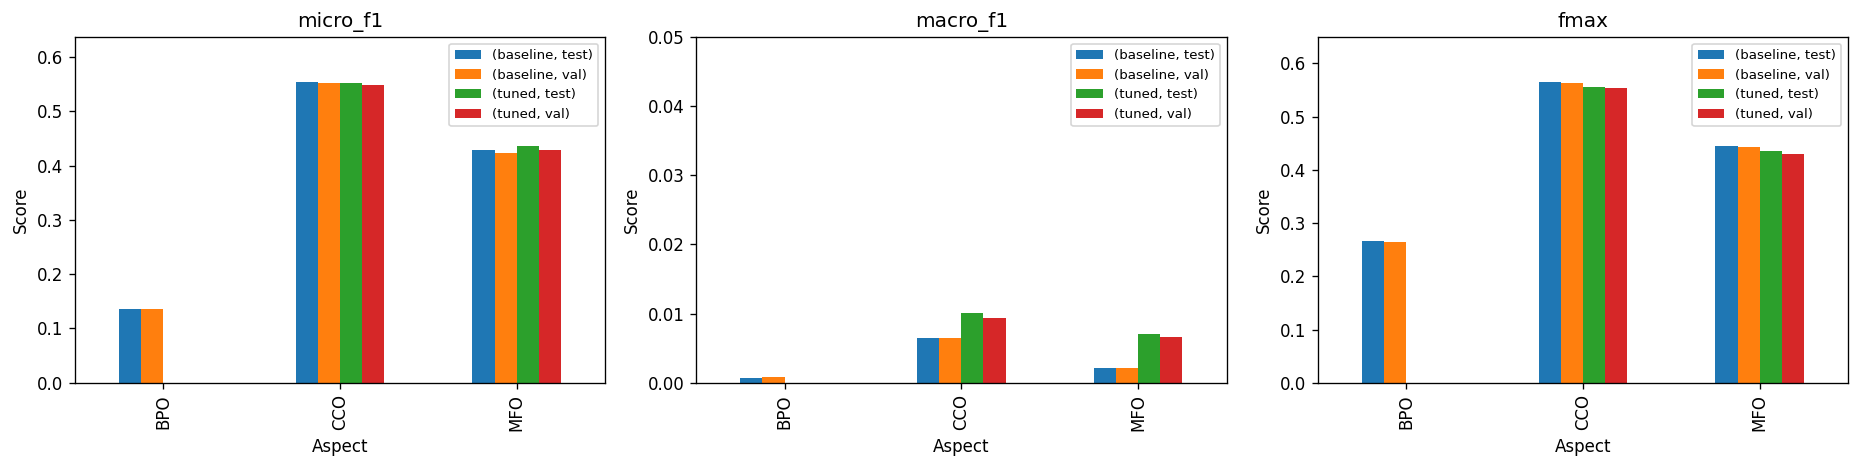

Saved /global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs/full_graph_tuned_pyg_mtf20_33275343/analysis_figures_tuned/final_metric_comparison_tuned_vs_baseline.png


In [8]:
plot_rows = []
for _, row in results_df.iterrows():
    for split in ('val', 'test'):
        for metric in ('micro_f1', 'macro_f1', 'fmax'):
            col = f'{split}_{metric}'
            value = pd.to_numeric(row.get(col), errors='coerce')
            if pd.notna(value):
                plot_rows.append({'run': row['run'], 'aspect': row['aspect'], 'split': split, 'metric': metric, 'value': value})
plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    display(Markdown('No final metric values are available to plot.'))
else:
    metrics = ['micro_f1', 'macro_f1', 'fmax']
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.2 * len(metrics), 4), squeeze=False)
    for ax, metric in zip(axes[0], metrics):
        pivot = plot_df[plot_df['metric'] == metric].pivot_table(index='aspect', columns=['run', 'split'], values='value', aggfunc='first')
        pivot = pivot.sort_index()
        pivot.plot(kind='bar', ax=ax)
        ax.set_title(metric)
        ax.set_xlabel('Aspect')
        ax.set_ylabel('Score')
        ax.set_ylim(0, max(0.05, min(1.0, plot_df[plot_df['metric'] == metric]['value'].max() * 1.15)))
        ax.legend(fontsize=8)
    fig.tight_layout()
    out_path = FIGURE_DIR / 'final_metric_comparison_tuned_vs_baseline.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')


## 9. Learning Curves

These curves compare per-epoch loss and Fmax. They make it clear when tuning helped early macro behavior but did not improve the final Fmax.


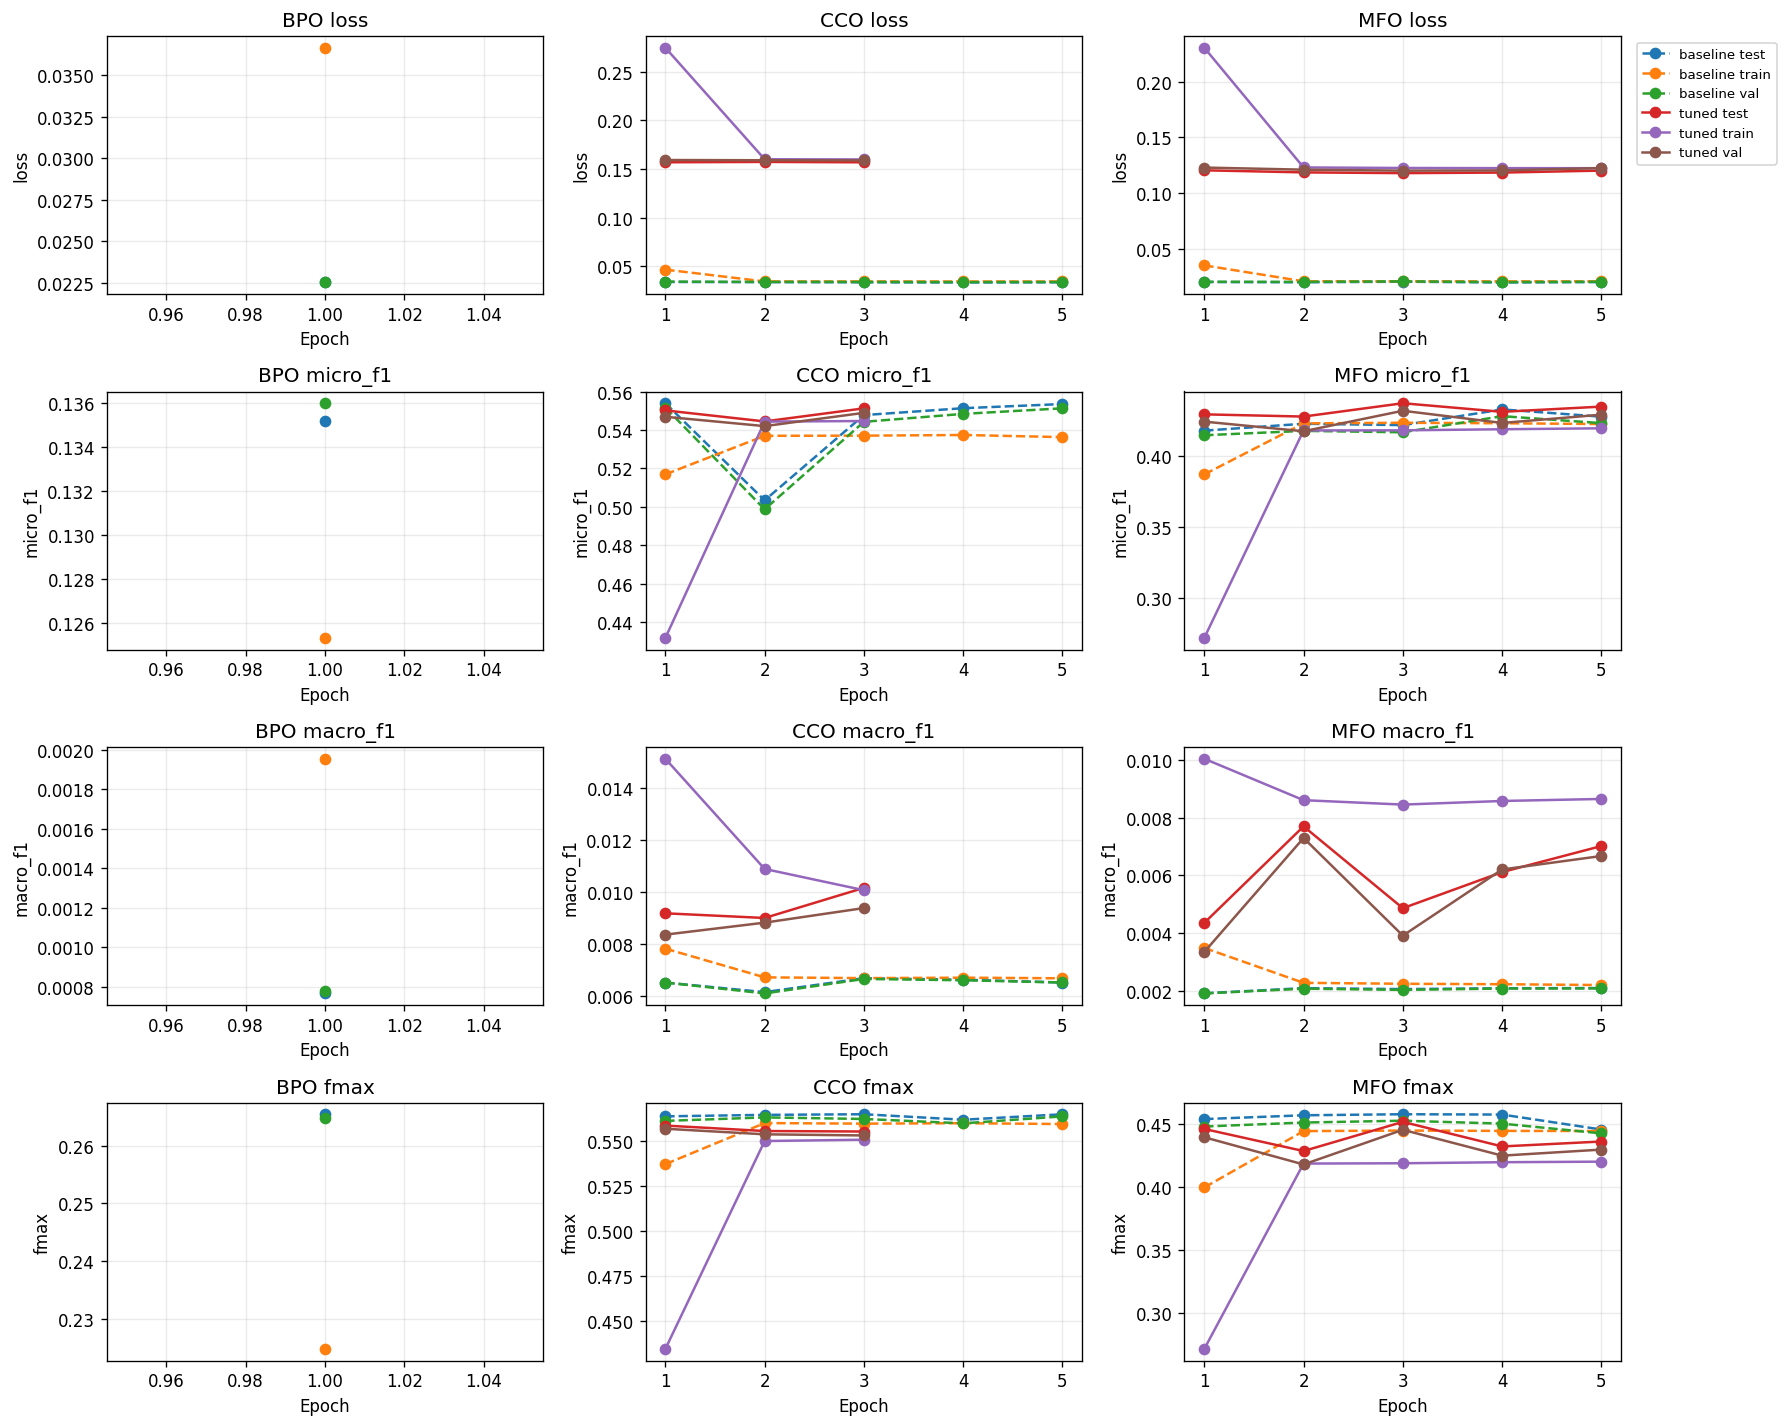

Saved /global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs/full_graph_tuned_pyg_mtf20_33275343/analysis_figures_tuned/learning_curves_tuned_vs_baseline.png


In [9]:
if epoch_df.empty:
    display(Markdown('No per-epoch histories were found.'))
else:
    for col in ('epoch', 'loss', 'micro_f1', 'macro_f1', 'fmax', 'lr', 'checkpoint_metric_value'):
        if col in epoch_df.columns:
            epoch_df[col] = pd.to_numeric(epoch_df[col], errors='coerce')
    aspects = sorted(epoch_df['aspect'].dropna().unique())
    metrics = ['loss', 'micro_f1', 'macro_f1', 'fmax']
    fig, axes = plt.subplots(len(metrics), len(aspects), figsize=(5 * max(1, len(aspects)), 3 * len(metrics)), squeeze=False)
    for row_index, metric in enumerate(metrics):
        for col_index, aspect in enumerate(aspects):
            ax = axes[row_index][col_index]
            subset = epoch_df[(epoch_df['aspect'] == aspect) & epoch_df[metric].notna()].sort_values('epoch')
            for (run, split), group in subset.groupby(['run', 'split']):
                style = '-' if run == 'tuned' else '--'
                ax.plot(group['epoch'], group[metric], marker='o', linestyle=style, label=f'{run} {split}')
            ax.set_title(f'{aspect} {metric}')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(metric)
            ax.grid(True, alpha=0.25)
            if row_index == 0 and col_index == len(aspects) - 1:
                ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    out_path = FIGURE_DIR / 'learning_curves_tuned_vs_baseline.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')


## 10. Learning Rate, Checkpoint Metric, and Thresholds

This cell checks whether the tuned scheduler and Fmax checkpoint metric were recorded correctly.


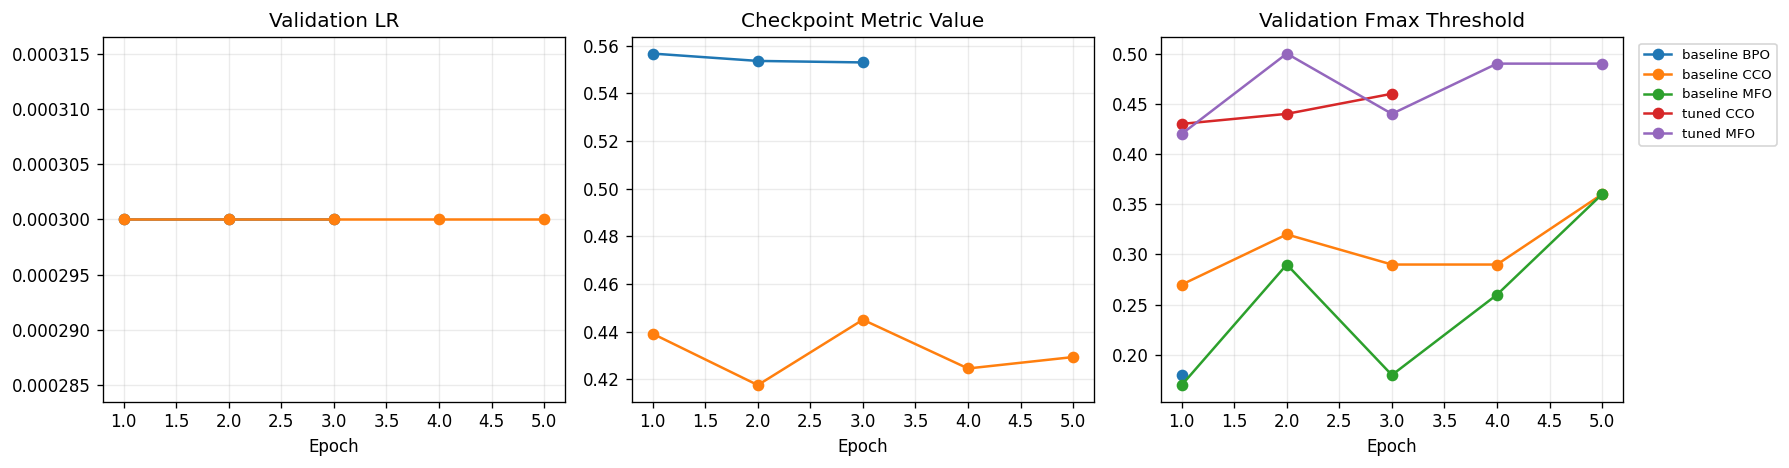

Saved /global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs/full_graph_tuned_pyg_mtf20_33275343/analysis_figures_tuned/lr_checkpoint_thresholds_tuned_vs_baseline.png


In [10]:
if epoch_df.empty:
    display(Markdown('No epoch data available for LR and threshold plots.'))
else:
    val_epochs = epoch_df[epoch_df['split'] == 'val'].copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), squeeze=False)
    for (run, aspect), group in val_epochs.groupby(['run', 'aspect']):
        group = group.sort_values('epoch')
        label = f'{run} {aspect}'
        if 'lr' in group and group['lr'].notna().any():
            axes[0][0].plot(group['epoch'], group['lr'], marker='o', label=label)
        if 'checkpoint_metric_value' in group and group['checkpoint_metric_value'].notna().any():
            axes[0][1].plot(group['epoch'], group['checkpoint_metric_value'], marker='o', label=label)
        if 'fmax_threshold' in group and group['fmax_threshold'].notna().any():
            axes[0][2].plot(group['epoch'], group['fmax_threshold'], marker='o', label=label)
    axes[0][0].set_title('Validation LR')
    axes[0][1].set_title('Checkpoint Metric Value')
    axes[0][2].set_title('Validation Fmax Threshold')
    for ax in axes[0]:
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.25)
    axes[0][2].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    out_path = FIGURE_DIR / 'lr_checkpoint_thresholds_tuned_vs_baseline.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')


## 11. Runtime and Progress Logs

This cell compares runtime and parses progress lines from `train.log`. The BPO tuned failure still has runtime metadata even though it has no summary.


,run,aspect,status,status_code,gpu_id,duration_hours,summary_exists,train_log_exists,checkpoint_dir
0,baseline,BPO,failed,1,srun-auto,15.531389,True,True,/global/scratch/users/bensonli/cafa5_outputs/g...
3,tuned,BPO,failed,1,srun-auto,11.829167,False,True,/global/scratch/users/bensonli/cafa5_outputs/g...
1,baseline,CCO,success,0,srun-auto,28.364722,True,True,/global/scratch/users/bensonli/cafa5_outputs/g...
4,tuned,CCO,success,0,srun-auto,36.017222,True,True,/global/scratch/users/bensonli/cafa5_outputs/g...
2,baseline,MFO,success,0,srun-auto,23.469722,True,True,/global/scratch/users/bensonli/cafa5_outputs/g...
5,tuned,MFO,success,0,srun-auto,49.199722,True,True,/global/scratch/users/bensonli/cafa5_outputs/g...


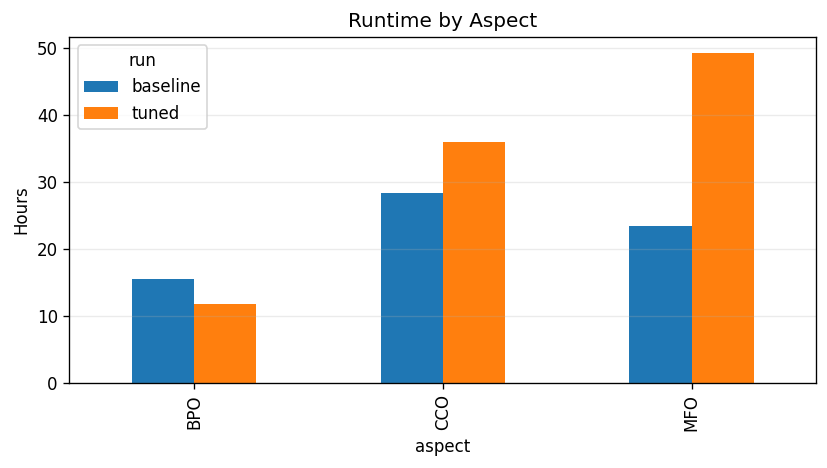

Saved /global/scratch/users/bensonli/cafa5_outputs/graph_cache/training_runs/full_graph_tuned_pyg_mtf20_33275343/analysis_figures_tuned/runtime_tuned_vs_baseline.png


,run,aspect,progress_lines,last_epoch,last_batch,min_loss,last_loss
0,baseline,BPO,732,2,8075,0.0164,0.0233
1,baseline,CCO,2090,5,8261,0.0198,0.0333
2,baseline,MFO,1850,5,7303,0.0129,0.0200
3,tuned,BPO,324,1,8075,0.2235,0.2235
4,tuned,CCO,1254,3,8261,0.1130,0.1569
5,tuned,MFO,1850,5,7303,0.0962,0.1201


In [11]:
runtime_df = run_result_df.copy()
if runtime_df.empty:
    display(Markdown('No run_result.json files were loaded.'))
else:
    for col in ('started_at', 'finished_at'):
        if col in runtime_df.columns:
            runtime_df[col] = pd.to_datetime(runtime_df[col], errors='coerce')
    if {'started_at', 'finished_at'}.issubset(runtime_df.columns):
        runtime_df['duration_hours'] = (runtime_df['finished_at'] - runtime_df['started_at']).dt.total_seconds() / 3600
    runtime_cols = ['run', 'aspect', 'status', 'status_code', 'gpu_id', 'duration_hours', 'summary_exists', 'train_log_exists', 'checkpoint_dir']
    runtime_display = runtime_df[[col for col in runtime_cols if col in runtime_df.columns]].sort_values(['aspect', 'run'])
    runtime_display.to_csv(FIGURE_DIR / 'runtime_tuned_vs_baseline.tsv', sep='\t', index=False)
    display(runtime_display)

    if 'duration_hours' in runtime_df.columns and runtime_df['duration_hours'].notna().any():
        pivot = runtime_df.pivot_table(index='aspect', columns='run', values='duration_hours', aggfunc='first')
        ax = pivot.sort_index().plot(kind='bar', figsize=(7, 4))
        ax.set_ylabel('Hours')
        ax.set_title('Runtime by Aspect')
        ax.grid(True, axis='y', alpha=0.25)
        fig = ax.get_figure()
        fig.tight_layout()
        out_path = FIGURE_DIR / 'runtime_tuned_vs_baseline.png'
        fig.savefig(out_path, bbox_inches='tight')
        plt.show()
        print(f'Saved {out_path}')

progress_pattern = re.compile(
    r'\[progress\]\s+epoch=(?P<epoch>\d+)\s+(?P<label>.+?)\s+batch=(?P<batch>\d+)/(?:\?|(?P<total_batches>\d+))\s+graphs=(?P<graphs>\d+)\s+loss=(?P<loss>[-+0-9.eE]+)'
)
progress_rows = []
for _, row in logs_df.iterrows():
    for line in str(row.get('train_log', '')).splitlines():
        match = progress_pattern.search(line)
        if match:
            record = match.groupdict()
            record.update({'run': row['run'], 'aspect': row['aspect']})
            progress_rows.append(record)
progress_df = pd.DataFrame(progress_rows)
if progress_df.empty:
    display(Markdown('No progress lines matched the expected train.log pattern.'))
else:
    for col in ('epoch', 'batch', 'total_batches', 'graphs', 'loss'):
        progress_df[col] = pd.to_numeric(progress_df[col], errors='coerce')
    progress_summary = progress_df.groupby(['run', 'aspect']).agg(
        progress_lines=('loss', 'size'),
        last_epoch=('epoch', 'max'),
        last_batch=('batch', 'max'),
        min_loss=('loss', 'min'),
        last_loss=('loss', 'last'),
    ).reset_index()
    progress_summary.to_csv(FIGURE_DIR / 'progress_summary_tuned_vs_baseline.tsv', sep='\t', index=False)
    display(progress_summary)


## 12. Notes

BPO: tuned status is failed; baseline status was failed. Metric deltas are unavailable when tuned metrics are missing.   
CCO: tuned test Fmax decreased by -0.0096 (validation Fmax -0.0106; test macro-F1 +0.0036).   
MFO: tuned test Fmax decreased by -0.0095 (validation Fmax -0.0128; test macro-F1 +0.0049).   
Best tuned test Fmax among successful aspects: CCO at 0.5551.   
Tuned successful aspects used weighted BCE with square-root softened positive weights capped at 20; this raised macro-F1 but did not improve Fmax for CCO or MFO in this run.   